# Lab 01: Bigdata Distributed Processing System for Digital Twins

A real city continuously generates observations of temperature, wind, and radiation. If a virtual city updates its state whenever new observations arrive, and then uses that updated state to forecast what happens next, we have a digital twin. This semester, we will build this closed loop ourselves. Today, we begin by looking at the entire structure and building a miniature version of the semester’s workflow in a 40-line simulation.

> **Preview of the running example:** the 2D temperature field we build today
> comes back in Weeks 10–13 as serial → OpenMP → MPI → JAX → observation update.
> Today's goal is to be convinced *by numbers* of why that journey is worth it.

## Learning Objectives

By the end of this lab you will be able to:

- Explain the **closed-loop structure** of a digital twin (observation → state
  update → forecast) in your own words, and map it onto real systems such as
  DestinE and NOAA EODT.
- Draw a system diagram of the pipeline,
  connected to the tools of each week (Spark, Xarray/Dask, OpenMP/MPI, JAX).
- Estimate the **data volume** of real observational datasets and explain why
  distributed and parallel processing is needed.
<!-- - Understand the Kaggle competition's problem definition, evaluation metric
  (RMSE), milestones and the score conversion formula. -->


In [1]:

%matplotlib inline
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.size"] = 11
rng = np.random.default_rng(0)   # fixed seed for reproducibility
print("numpy", np.__version__)


numpy 2.3.3


---
## 1. What is a digital twin?

A **digital twin** is a virtual model of a real physical system that is continuously updated using observational data. What separates it from a
static simulation or a one-shot forecast is the **closed loop**:

| Component | Role |
|---|---|
| Physical twin | The real city / atmosphere, where observations are collected |
| Virtual twin | The numerical model that advances the state |
| Observation feedback | When observations arrive, update or correct the virtual state |
| Forecast & dashboard | The updated state is used to forecast what happens next |

The key idea is not simply that “we use an AI model.” A digital twin has a **continuous feedback structure**: observations from the physical system update the virtual state, and the updated state is then used to make a new forecast.

### Real systems

| System | Organization | What it twins |
|---|---|---|
| Destination Earth (DestinE) | ECMWF / EU | Earth's climate and weather (km scale) |
| Earth Observations Digital Twin (EO-DT) | NOAA | An observation-driven digital representation of the Earth system |
| Our course project | Course410 | Urban thermal environment (temperature over a two-dimensional city grid) |


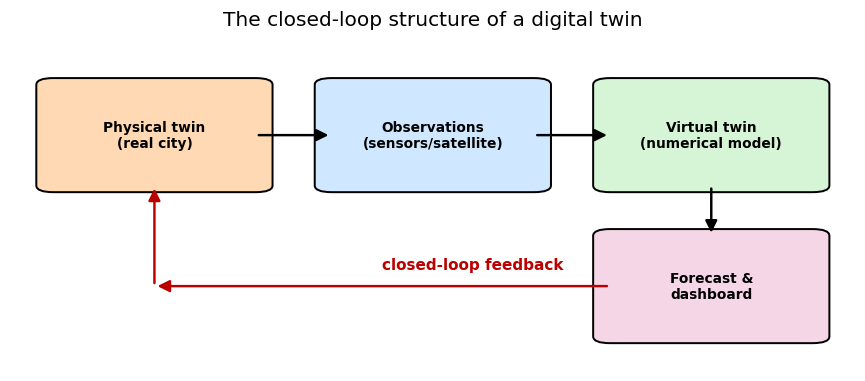

In [2]:

# Draw the closed-loop structure ourselves (pin the concept down in code).
def box(ax, xy, w, h, text, fc, fs=10):
    ax.add_patch(FancyBboxPatch(xy, w, h, boxstyle="round,pad=0.02",
                                fc=fc, ec="black", lw=1.3))
    ax.text(xy[0] + w/2, xy[1] + h/2, text, ha="center", va="center",
            fontsize=fs, weight="bold")

def arrow(ax, p0, p1, color="black", style="-|>"):
    ax.add_patch(FancyArrowPatch(p0, p1, arrowstyle=style, mutation_scale=16,
                                 lw=1.6, color=color))

fig, ax = plt.subplots(figsize=(8, 3.6))
box(ax, (0.05, 0.55), 0.24, 0.30, "Physical twin\n(real city)", "#ffd9b3", fs=9)
box(ax, (0.38, 0.55), 0.24, 0.30, "Observations\n(sensors/satellite)", "#cfe8ff", fs=9)
box(ax, (0.71, 0.55), 0.24, 0.30, "Virtual twin\n(numerical model)", "#d6f5d6", fs=9)
box(ax, (0.71, 0.10), 0.24, 0.30, "Forecast &\ndashboard", "#f5d6e6", fs=9)

arrow(ax, (0.29, 0.70), (0.38, 0.70))          # reality -> observations
arrow(ax, (0.62, 0.70), (0.71, 0.70))          # observations -> model (state update)
arrow(ax, (0.83, 0.55), (0.83, 0.40))          # model -> forecast
arrow(ax, (0.71, 0.25), (0.17, 0.25), "#b00")  # forecast -> compare with reality
arrow(ax, (0.17, 0.25), (0.17, 0.55), "#b00")
ax.text(0.44, 0.30, "closed-loop feedback", color="#b00", fontsize=10, weight="bold")
ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.axis("off")
ax.set_title("The closed-loop structure of a digital twin")
plt.tight_layout()


> **Observe:** without the red arrows (observation → state update → compare with
> reality again) this is just an ordinary simulation. Whether that feedback loop
> exists or not is exactly what will split the RMSE numbers in the second half of
> today's lab.

---
## 2. The five stages of the DT pipeline

The mandatory pipeline we will complete over 15 weeks looks like this:

```
ingest observations → align in space and time → forecast the state → update with observations → visualize and analyze
```

Each stage maps to specific tools and weeks:

| Stage | Tools | Weeks |
|---|---|---|
| ① Ingest observations | OpenAPI, satellites (GEE/COG/STAC) | 5, 9 |
| ② Align & aggregate in space-time | Spark, Xarray/Dask, NetCDF/Zarr | 3–4, 6–7 |
| ③ Forecast state | Heat-diffusion simulator (serial→OpenMP→MPI→JAX) | 10–12 |
| ④ Update with observations | Nudging / state estimation | 13 |
| ⑤ Dashboard & analysis | Integration, ablation | 14–15 |

The important point is that these are not five separate exercises. Each stage becomes one part of the same system. By the end of the semester, observations will enter the pipeline, be processed and aligned, update a numerical model, and produce a new forecast and visualization — completing the digital twin loop.


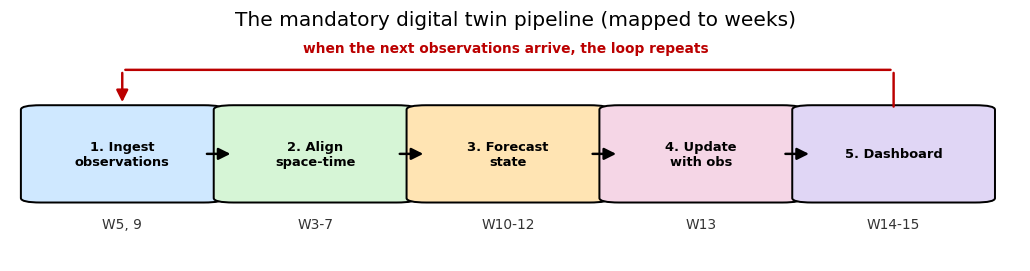

In [3]:

# Visualize the five-stage pipeline as a horizontal flow.
stages = ["1. Ingest\nobservations", "2. Align\nspace-time", "3. Forecast\nstate",
          "4. Update\nwith obs", "5. Dashboard"]
weeks  = ["W5, 9", "W3-7", "W10-12", "W13", "W14-15"]
colors = ["#cfe8ff", "#d6f5d6", "#ffe4b3", "#f5d6e6", "#e0d6f5"]

fig, ax = plt.subplots(figsize=(9.5, 2.6))
x, w = 0.03, 0.165
centers = []
for s, wk, c in zip(stages, weeks, colors):
    box(ax, (x, 0.28), w, 0.40, s, c, fs=8.5)
    ax.text(x + w/2, 0.16, wk, ha="center", va="center", fontsize=9, color="#333")
    if x > 0.03:
        arrow(ax, (x - 0.03, 0.48), (x, 0.48))
    centers.append(x + w/2)
    x += w + 0.03
# Closed loop: the dashboard feeds back into ingestion (routed above the boxes)
arrow(ax, (centers[-1], 0.68), (centers[-1], 0.86), "#b00", style="-")
arrow(ax, (centers[-1], 0.86), (centers[0], 0.86), "#b00", style="-")
arrow(ax, (centers[0], 0.86), (centers[0], 0.70), "#b00")
ax.text(0.5, 0.94, "when the next observations arrive, the loop repeats",
        ha="center", color="#b00", fontsize=9, weight="bold")
ax.set_xlim(0, 1.02); ax.set_ylim(0, 1.02); ax.axis("off")
ax.set_title("The mandatory digital twin pipeline (mapped to weeks)")
plt.tight_layout()


We will walk through all five stages of the digital twin pipeline on a very small scale. Section 3 covers ①–② (observations and alignment), Sections 4–5 cover ③ (forecasting), Section 6 covers ④ (state update), and Section 7 covers ⑤ (evaluation) — each with just a few lines of code.

The rest of the semester will be about scaling up each of these pieces: from this small prototype to a system that is large-scale, reproducible, and parallel.

---
## 3. Making observations — a synthetic urban temperature field

We will start working with real observational data in Week 5. For today, we first build a synthetic “real city” so that we can experiment with the digital twin while still knowing the exact ground truth.

We represent the city as an N\times N grid and assume that the temperature in each grid cell evolves according to the heat diffusion equation:

$$ \frac{\partial T}{\partial t} = \alpha\,\nabla^2 T + f(x, y, t) $$

- $\alpha$: thermal diffusivity
- $f$: external heat input, representing effects such as daytime solar heating and nighttime cooling

We advance this equation in time using a simple explicit finite-difference scheme. To keep the numerical solution stable, the time step must satisfy. 
The time step must satisfy $\alpha\,\Delta t / \Delta x^2 \le 1/4$ (revisited in Week 10).


In [4]:

# --- Grid and discretization parameters (the same notation returns in Weeks 10-13) ---
N   = 50            # cells per side
dx  = 1.0           # grid spacing dx (grid units)
dt  = 1.0           # time step dt
alpha = 0.20        # thermal diffusivity alpha

# 5-point Laplacian (insulated boundary: Neumann approximated by edge replication)
def laplacian(T):
    Tp = np.pad(T, 1, mode="edge")
    return (Tp[2:, 1:-1] + Tp[:-2, 1:-1] +
            Tp[1:-1, 2:] + Tp[1:-1, :-2] - 4.0 * T) / dx**2

def diffuse(T):
    return T + alpha * dt * laplacian(T)

cfl = alpha * dt / dx**2
print(f"diffusion CFL number  α·Δt/Δx² = {cfl:.3f}   (stable if <= 0.25 -> {'OK' if cfl <= 0.25 else 'UNSTABLE'})")


diffusion CFL number  α·Δt/Δx² = 0.200   (stable if <= 0.25 -> OK)


initial temperature range: 15.0 ~ 23.0 °C


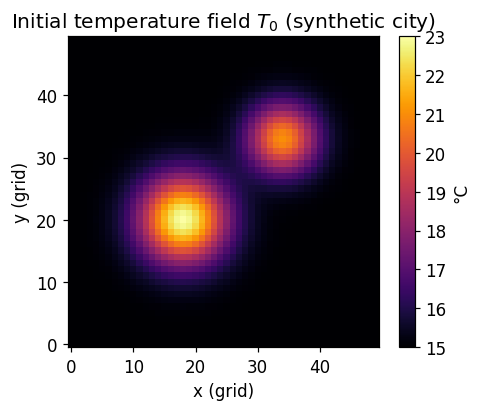

In [5]:

# --- Initial temperature field: two urban heat islands on a background ---
yy, xx = np.mgrid[0:N, 0:N]
def hotspot(cx, cy, amp, sig):
    return amp * np.exp(-((xx - cx)**2 + (yy - cy)**2) / (2 * sig**2))

T0 = 15.0 + hotspot(18, 20, 8.0, 5.0) + hotspot(34, 33, 6.0, 4.0)
print(f"initial temperature range: {T0.min():.1f} ~ {T0.max():.1f} °C")

fig, ax = plt.subplots(figsize=(4.6, 3.8))
im = ax.imshow(T0, origin="lower", cmap="inferno")
ax.set_title("Initial temperature field $T_0$ (synthetic city)")
ax.set_xlabel("x (grid)"); ax.set_ylabel("y (grid)")
fig.colorbar(im, ax=ax, label="°C")
plt.tight_layout()


In [6]:

# --- The "real city" heat input f(x,y,t): a moving heat island + a diurnal cycle ---
P = 48                       # diurnal period (imagine 48 steps = one day)
def forcing(t):
    # the heat source centre travels in a circle (movement of urban activity)
    cx = 25 + 10 * np.cos(2 * np.pi * t / (2 * P))
    cy = 25 + 10 * np.sin(2 * np.pi * t / (2 * P))
    diurnal = 0.5 + 0.5 * np.sin(2 * np.pi * t / P)   # day / night
    return 1.2 * diurnal * np.exp(-((xx - cx)**2 + (yy - cy)**2) / (2 * 4.0**2))

# March the synthetic real city forward:
# diffusion + a heat input that will be hidden from the forecast model
def truth_step(T, t):
    return diffuse(T) + dt * forcing(t)

STEPS = 200
truth = np.empty((STEPS + 1, N, N))
truth[0] = T0
for t in range(STEPS):
    truth[t + 1] = truth_step(truth[t], t)

print(f"real city marched {STEPS} steps. final temperature range "
      f"{truth[-1].min():.1f} ~ {truth[-1].max():.1f} °C")


real city marched 200 steps. final temperature range 15.1 ~ 33.9 °C


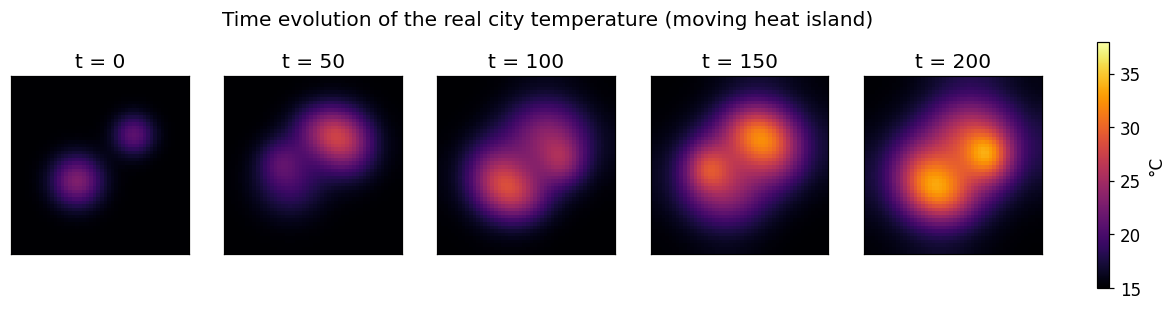

In [7]:

# A few snapshots of the real city
snaps = [0, 50, 100, 150, 200]
fig, axes = plt.subplots(1, len(snaps), figsize=(13, 2.9))
vmin, vmax = truth.min(), truth.max()
for ax, t in zip(axes, snaps):
    im = ax.imshow(truth[t], origin="lower", cmap="inferno", vmin=vmin, vmax=vmax)
    ax.set_title(f"t = {t}")
    ax.set_xticks([]); ax.set_yticks([])
fig.colorbar(im, ax=axes, label="°C", fraction=0.02)
fig.suptitle("Time evolution of the real city temperature (moving heat island)");


**Observe**: The CFL number is 0.20 ($\le 0.25$), so the simulation remains stable.

The synthetic city evolves in two ways: temperature spreads through diffusion, while a moving diurnal heat source continually changes the temperature field. Our forecast model, however, does not know this heat source $f$. As a result, an open-loop forecast gradually drifts away from the true state.

This is exactly why a digital twin needs observational updates: new observations can repeatedly bring the virtual state back toward the real system.

---
## 4. Forecast baseline — persistence 

The simplest forecast: assume **"the current state stays as it is."** This is
called **persistence**."

$$ \hat{T}(t + k) = T(t) $$

In other words, if the temperature is $25^\circ\mathrm{C}$ now, persistence predicts that it will remain $25^\circ\mathrm{C}$ at every future time we consider.

This may seem overly simple, but persistence can be surprisingly difficult to beat at short lead times because temperature fields usually change gradually.
It therefore provides a natural baseline that every forecasting model should beat.


In [8]:

# persistence: copy the state at time t0 into the future as the forecast.
def rmse(a, b):
    return float(np.sqrt(np.mean((a - b)**2)))

t0 = 100
horizons = [1, 3, 6, 12, 24]
print(f"{'lead time (steps)':>18} | {'persistence RMSE (°C)':>26}")
print("-" * 48)
for k in horizons:
    err = rmse(truth[t0], truth[t0 + k])   # forecast = truth[t0], target = truth[t0+k]
    print(f"{k:>18} | {err:>26.3f}")


 lead time (steps) |      persistence RMSE (°C)
------------------------------------------------
                 1 |                      0.119
                 3 |                      0.377
                 6 |                      0.794
                12 |                      1.586
                24 |                      2.281


> **Observe:** the longer the lead time, the larger the persistence error. One
> step ahead is fine; 24 steps ahead misses badly. The real competition task is
> also "temperature 1–6 hours ahead", so at short lead times persistence is a
> formidable opponent.

---
## 5. Open-loop simulation — why the model alone is not enough

Now we forecast by running a **numerical model**. Our model only accounts for heat diffusion; the external heat input $f$ that drives the synthetic real city is not included in the forecast model.

The model starts from the same initial state as the real city, but if it continues on its own without receiving any observations — an open-loop forecast — it gradually drifts away from the real city.


In [9]:

# The model only knows diffusion (no forcing term). Marching with no observations = open loop.
def model_step(T):
    return diffuse(T)

open_loop = np.empty_like(truth)
open_loop[0] = T0.copy()
for t in range(STEPS):
    open_loop[t + 1] = model_step(open_loop[t])

rmse_open = np.array([rmse(open_loop[t], truth[t]) for t in range(STEPS + 1)])
print(f"open-loop RMSE:  initial {rmse_open[0]:.3f} -> final {rmse_open[-1]:.3f} °C")


open-loop RMSE:  initial 0.000 -> final 6.756 °C


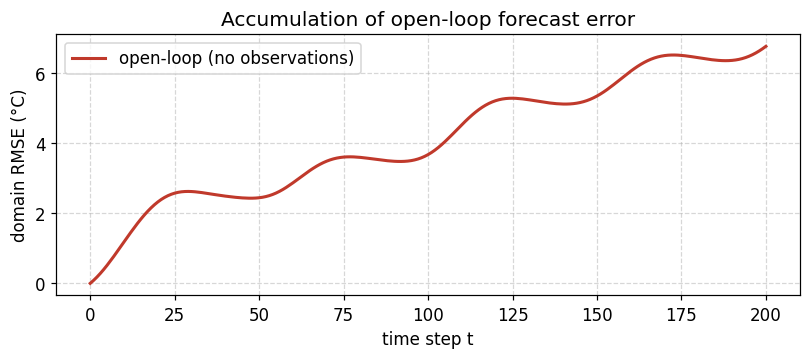

In [10]:

fig, ax = plt.subplots(figsize=(7.5, 3.4))
ax.plot(rmse_open, lw=2, color="#c0392b", label="open-loop (no observations)")
ax.set_xlabel("time step t"); ax.set_ylabel("domain RMSE (°C)")
ax.set_title("Accumulation of open-loop forecast error")
ax.grid(True, ls="--", alpha=0.5); ax.legend()
plt.tight_layout()


**Observe**: The open-loop error grows over time because the forecast model does not include the external heat input $f$, so the effect of this missing process accumulates.

In real applications, even a highly accurate physical model cannot represent every process perfectly. Observations provide a way to correct these model errors and bring the virtual state back toward the real system.

---
## 6. Closing the loop — updating the state with observations (one line of nudging)

Now we close the loop. Suppose sensors placed around the city measure temperature at a small number of grid points, with some observational noise.

After each forecast step, we adjust the model state at the observed locations by moving it toward the sensor measurements:

$$ T \leftarrow T + \kappa\,(y_{\text{obs}} - T)\quad\text{(at observed points only)} $$

This simple update is called nudging. 
Nudging is mathematically similar to a relaxation or damping term, except that the target is the observation.

The parameter $\kappa$ controls how strongly we trust the observations. With $\kappa=0$, no correction is made and the system remains open loop. With $\kappa=1$, the model value at each observed point is replaced completely by the observation.

we will study the effects of update frequency, observation density, noise, and nudging strength more carefully. 

For today, we focus on one simple question: how much can this one-line update reduce the RMSE?

In [11]:

# Fixed sensor locations (25 of them around the city), observation noise sigma_obs
n_sensors = 25
sy = rng.integers(0, N, n_sensors)
sx = rng.integers(0, N, n_sensors)
sigma_obs = 0.3          # observation noise (°C)
kappa = 0.5              # nudging strength

def observe(t):
    # observe the real city at the sensor points, with noise
    return truth[t, sy, sx] + rng.normal(0, sigma_obs, n_sensors)

# Closed loop: march the model, then pull the observed points toward the observations
closed = np.empty_like(truth)
closed[0] = T0.copy()
for t in range(STEPS):
    T = model_step(closed[t])
    y = observe(t + 1)
    T[sy, sx] += kappa * (y - T[sy, sx])   # <- the one line of nudging
    closed[t + 1] = T

rmse_closed = np.array([rmse(closed[t], truth[t]) for t in range(STEPS + 1)])
print(f"closed-loop RMSE: initial {rmse_closed[0]:.3f} -> final {rmse_closed[-1]:.3f} °C")
print(f"final improvement: {(1 - rmse_closed[-1] / rmse_open[-1]) * 100:.1f}%  "
      f"(open {rmse_open[-1]:.3f} -> closed {rmse_closed[-1]:.3f})")


closed-loop RMSE: initial 0.000 -> final 5.340 °C
final improvement: 21.0%  (open 6.756 -> closed 5.340)


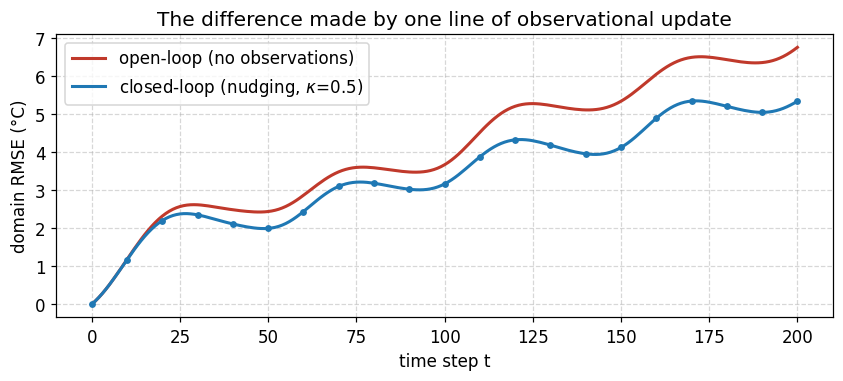

In [12]:

fig, ax = plt.subplots(figsize=(7.8, 3.6))
ax.plot(rmse_open,   lw=2, color="#c0392b", label="open-loop (no observations)")
ax.plot(rmse_closed, lw=2, color="#1f78b4", label=f"closed-loop (nudging, $\\kappa$={kappa})")
ax.scatter(range(0, STEPS + 1, 10), rmse_closed[::10], s=12, color="#1f78b4", zorder=3)
ax.set_xlabel("time step t"); ax.set_ylabel("domain RMSE (°C)")
ax.set_title("The difference made by one line of observational update")
ax.grid(True, ls="--", alpha=0.5); ax.legend()
plt.tight_layout()


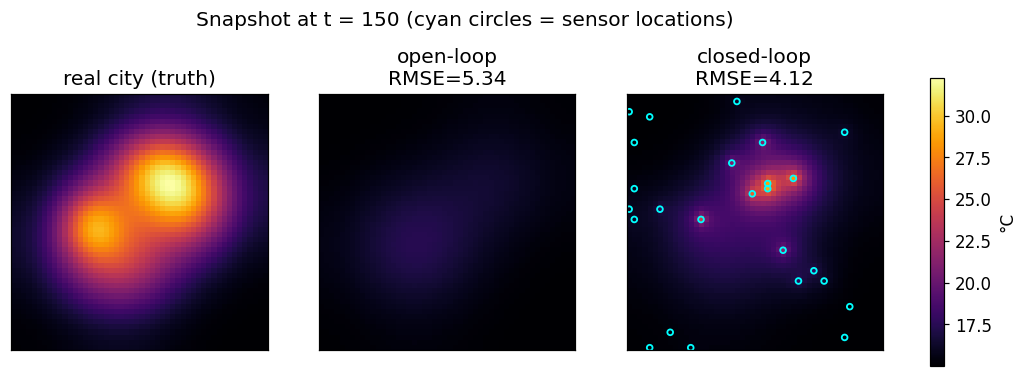

In [13]:

# Truth / open-loop / closed-loop side by side at the same instant
t_show = 150
fields = [truth[t_show], open_loop[t_show], closed[t_show]]
titles = ["real city (truth)", f"open-loop\nRMSE={rmse_open[t_show]:.2f}",
          f"closed-loop\nRMSE={rmse_closed[t_show]:.2f}"]
vmin, vmax = truth[t_show].min(), truth[t_show].max()
fig, axes = plt.subplots(1, 3, figsize=(11, 3.4))
for ax, F, tt in zip(axes, fields, titles):
    im = ax.imshow(F, origin="lower", cmap="inferno", vmin=vmin, vmax=vmax)
    ax.set_title(tt); ax.set_xticks([]); ax.set_yticks([])
axes[2].scatter(sx, sy, s=14, facecolors="none", edgecolors="cyan", lw=1.2)
fig.colorbar(im, ax=axes, label="°C", fraction=0.02)
fig.suptitle(f"Snapshot at t = {t_show} (cyan circles = sensor locations)", y=1.06);


**Observe**: With just 25 sensors, a simple nudging update reduces the RMSE from 5.34 to 4.12. The open-loop model misses the warm regions almost entirely, while the closed-loop model recovers part of their structure from the observations.

The observations do not tell the model the missing forcing $f$ directly. Instead, they repeatedly correct the model state, and these corrections spread through the model dynamics. This is the basic idea of the digital-twin loop: forecast, observe, correct, and forecast again.

<!-- ---
## 7. The Kaggle competition — the problem we compete on

The evaluation axis of this semester is a **Kaggle Community Competition (private
leaderboard)**.

> Using the past 24 hours of weather observations and satellite features,
> **forecast the temperature 1–6 hours ahead for each grid cell**.

- **Metric:** RMSE (lower is better), 5 submissions per day
- **Data:** summer 2025 observations (frozen in August before the semester) —
  train / public / private

### Mandatory milestones

| Model | Content | Due |
|---|---|---|
| M0 | persistence / climatology baseline | Week 5 |
| M1 | observation-based ML model | Week 8 |
| M2 | simple physical simulator (MPI heat diffusion) | Week 11 |
| M3 | hybrid twin updated by observations | Week 13 |
| M4 | free-form model | Week 14 |

You are graded not on a single best score but on the **process of improvement and
analysis from M0 to M3**. The persistence (M0), open-loop and closed-loop models
we built today are miniatures of M0, M2 and M3. -->


In [14]:

# Treat the three methods as competing submissions and evaluate them using
# the mean RMSE over the entire city grid and over continuous operation.
# Although only 25 sensor locations are observed, the score is computed
# over all grid cells, just as in the course competition.

warm = 20   # ignore the initial transient when computing the continuous-operation score
lead = 6
def field_persistence(t):        # forecast = the state `lead` steps ago (all-grid persistence)
    return truth[t - lead]

board = {
    f"M0 persistence (lead {lead})":
        float(np.mean([rmse(field_persistence(t), truth[t]) for t in range(warm, STEPS + 1)])),
    "M2 open-loop sim":
        float(np.mean([rmse(open_loop[t], truth[t]) for t in range(warm, STEPS + 1)])),
    "M3 closed-loop twin":
        float(np.mean([rmse(closed[t], truth[t]) for t in range(warm, STEPS + 1)])),
}
print(f"{'submission':<28}{'all-grid mean RMSE':>22}")
print("-" * 50)
for name, e in sorted(board.items(), key=lambda kv: kv[1]):
    print(f"{name:<28}{e:>22.3f}")
imp = (1 - board['M3 closed-loop twin'] / board['M2 open-loop sim']) * 100
print(
    f"\neffect of observational updates "
    f"(closed-loop vs open-loop): {imp:.1f}% improvement"
)

print(
    "note: short-lead persistence is a strong baseline; "
    "the closed-loop twin does not beat it yet."
)


submission                      all-grid mean RMSE
--------------------------------------------------
M0 persistence (lead 6)                      0.484
M3 closed-loop twin                          3.673
M2 open-loop sim                             4.440

effect of observational updates (closed-loop vs open-loop): 17.3% improvement
note: short-lead persistence is a strong baseline; the closed-loop twin does not beat it yet.


> **Observe:** persistence is an extremely strong baseline at short lead times,
> so today's twin does **not** immediately beat it on all-grid RMSE — which is
> exactly why persistence is the bar that must be cleared (**M0**). Still, the
> observational update (1) clearly reduces the error relative to open-loop, and
> (2) does not collapse as the lead time grows (the two figures above). **The
> M0→M3 journey of this course is itself the process of finally overtaking a
> strong persistence baseline with physics + observations.** The score conversion
> formula rewards each step of that journey by scoring improvement over the
> baseline rather than rank.

---
## 8. A sense of big-data scale — why distributed and parallel processing?

Today’s experiment uses only a 50\times50 grid for 200 time steps. A real urban thermal digital twin can be many orders of magnitude larger.
In this section, we estimate that scale and ask a simple question: could a single laptop process and simulate it fast enough?
As the data volume and computational workload grow, a single-machine workflow eventually becomes impractical. The rest of the course is largely about learning how to cross that boundary.


In [15]:
# Rough storage estimates for increasingly realistic digital-twin datasets.
# Assume every value is stored as float32 (4 bytes).

GB = 1024**3

scenarios = {
    "today's lab (50x50, 1 var, 200 steps)":
        (50, 50, 1, 200),
    "city-scale (1000x1000, 1 var, hourly for 1 year)":
        (1000, 1000, 1, 24 * 365),
    "multivariate city twin (2000x2000, 8 vars, hourly for 1 year)":
        (2000, 2000, 8, 24 * 365),
    "ensemble twin (2000x2000, 8 vars, 20 members, hourly for 1 year)":
    (2000, 2000, 8 * 20, 24 * 365),
}

print(f"{'scenario':<65}{'values':>18}{'size (float32)':>18}")
print("-" * 101)

sizes = {}

for name, (nx, ny, nv, nt) in scenarios.items():
    n_values = nx * ny * nv * nt
    gb = n_values * 4 / GB
    sizes[name] = gb
    print(f"{name:<65}{n_values:>18,}{gb:>15.2f} GB")

scenario                                                                     values    size (float32)
-----------------------------------------------------------------------------------------------------
today's lab (50x50, 1 var, 200 steps)                                       500,000           0.00 GB
city-scale (1000x1000, 1 var, hourly for 1 year)                      8,760,000,000          32.63 GB
multivariate city twin (2000x2000, 8 vars, hourly for 1 year)       280,320,000,000        1044.27 GB
ensemble twin (2000x2000, 8 vars, 20 members, hourly for 1 year)  5,606,400,000,000       20885.47 GB


Today’s temperature dataset is only a few megabytes, so it easily fits in the memory of a laptop. A year-long multivariate city dataset can easily approach a terabyte even before we include multiple forecasts, ensemble members, satellite imagery, or intermediate outputs. At this scale, we can no longer assume that all data fit comfortably in memory or that every computation should run on a single CPU.

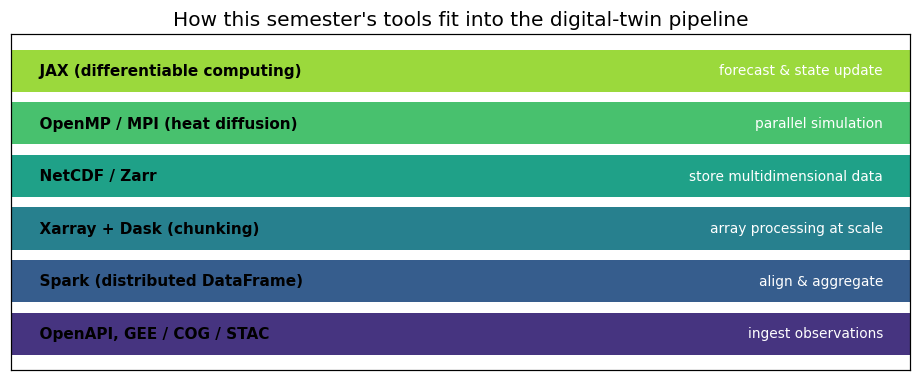

In [16]:
# Map each tool to its main role in the digital-twin pipeline.

tools = {
    "OpenAPI, GEE / COG / STAC":         "ingest observations",
    "Spark (distributed DataFrame)":     "align & aggregate",
    "Xarray + Dask (chunking)":          "array processing at scale",
    "NetCDF / Zarr":                     "store multidimensional data",
    "OpenMP / MPI (heat diffusion)":     "parallel simulation",
    "JAX (differentiable computing)":    "forecast & state update",
}

fig, ax = plt.subplots(figsize=(8.5, 3.6))

ax.barh(
    range(len(tools)),
    [1] * len(tools),
    color=plt.cm.viridis(np.linspace(0.15, 0.85, len(tools)))
)

for i, (tool, role) in enumerate(tools.items()):
    ax.text(
        0.02, i, f"  {tool}",
        va="center", fontsize=10, weight="bold"
    )

    ax.text(
        0.98, i, role + "  ",
        va="center", ha="right", fontsize=9, color="white"
    )

ax.set_yticks([])
ax.set_xticks([])
ax.set_xlim(0, 1)
ax.set_title("How this semester's tools fit into the digital-twin pipeline")

plt.tight_layout()

**Observe**: No single tool builds a digital twin. Each tool solves a different scaling problem — acquiring data, organizing it, storing it efficiently, running the forecast, or updating the model with observations.

---
## 🔬 Exercises

The exercises below are designed to build intuition by modifying the mini digital twin we developed today. A reference solution is provided after each exercise. Try solving the problem on your own first, then compare your approach with the reference solution.


**Exercise 1.** Vary the nudging strength $\kappa$ from 0 (open-loop) to 1 and
plot how the final RMSE changes. Is "believing the observations more strongly"
always better?


best kappa ~ 1.0, giving RMSE = 5.001 °C
A larger kappa corrects the model more strongly, but it also injects more observation noise.


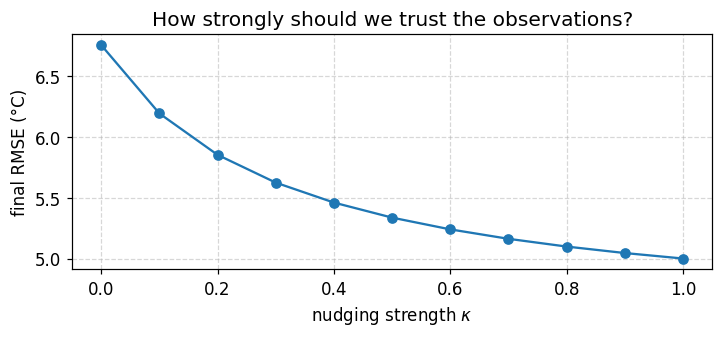

In [17]:
# Pre-generate one noisy observation sequence so every kappa sees the same data.
obs_noise = rng.normal(0, sigma_obs, size=(STEPS, n_sensors))

def run_closed(kappa):
    C = T0.copy()

    for t in range(STEPS):
        T = model_step(C)

        y = truth[t + 1, sy, sx] + obs_noise[t]

        T[sy, sx] += kappa * (y - T[sy, sx])
        C = T

    return rmse(C, truth[STEPS])


kappas = np.linspace(0, 1, 11)
final_rmse = [run_closed(k) for k in kappas]

fig, ax = plt.subplots(figsize=(6.8, 3.2))
ax.plot(kappas, final_rmse, "o-")
ax.set_xlabel("nudging strength $\\kappa$")
ax.set_ylabel("final RMSE (°C)")
ax.set_title("How strongly should we trust the observations?")
ax.grid(True, ls="--", alpha=0.5)
plt.tight_layout()

best = kappas[int(np.argmin(final_rmse))]

print(
    f"best kappa ~ {best:.1f}, "
    f"giving RMSE = {min(final_rmse):.3f} °C"
)

print(
    "A larger kappa corrects the model more strongly, "
    "but it also injects more observation noise."
)

**Exercise 2**. Increase the number of sensors from 5 to 25, 100, and 400. How does the RMSE change as the observation network becomes denser? Does each additional set of sensors provide the same amount of improvement, or do you observe diminishing returns?

In [ ]:
def run_with_sensors(n, seed=0):
    local_rng = np.random.default_rng(seed)
    # Choose n unique sensor locations from the N x N grid.
    ids = local_rng.choice(N * N, size=n, replace=False)
    ry, rx = np.unravel_index(ids, (N, N))
    C = T0.copy()
    for t in range(STEPS):
        T = model_step(C)
        y = (
            truth[t + 1, ry, rx]
            + local_rng.normal(0, sigma_obs, n)
        )
        T[ry, rx] += 0.5 * (y - T[ry, rx])
        C = T
    return rmse(C, truth[STEPS])


counts = [5, 25, 100, 400]
res = [run_with_sensors(n, seed=1) for n in counts]
for n, e in zip(counts, res):
    print(
        f"{n:>4} sensors -> final RMSE {e:.3f} °C  "
        f"({100*n/(N*N):.1f}% of the {N*N} grid cells)"
    )

   5 sensors -> final RMSE 6.142 °C  (0.2% of the 2500 grid cells)
  25 sensors -> final RMSE 5.114 °C  (1.0% of the 2500 grid cells)
 100 sensors -> final RMSE 2.724 °C  (4.0% of the 2500 grid cells)
 400 sensors -> final RMSE 0.974 °C  (16.0% of the 2500 grid cells)


**Exercise 3.** Replace persistence with climatology, defined here as the time-mean temperature field. How do the two baselines compare? Which one would you expect to perform better at short and long forecast lead times?


In [21]:
clim = truth.mean(axis=0)   # time-mean field = climatology
lead = 6

persist_errs = []
clim_errs = []

for t0 in range(warm, STEPS + 1 - lead):
    target = truth[t0 + lead]
    persist_errs.append(
        rmse(truth[t0], target)
    )
    clim_errs.append(
        rmse(clim, target)
    )

err_persist = float(np.mean(persist_errs))
err_clim = float(np.mean(clim_errs))
print(
    f"mean RMSE for a {lead}-step-ahead forecast  |  "
    f"persistence {err_persist:.3f}  vs  climatology {err_clim:.3f}"
)

# Persistence is usually strong at short lead times because the current state still contains useful information about the near future. Climatology ignores the current state and predicts the long-term mean, so it can become competitive when the forecast lead is long enough that the initial state has lost much of its predictive value.

mean RMSE for a 6-step-ahead forecast  |  persistence 0.476  vs  climatology 1.779


---
## Summary

Today we completed **a miniature of the whole semester** in about 40 lines:

- **A digital twin is a closed loop.**  Observations update the virtual state, and the updated state is then used to forecast what happens next. This feedback loop is what distinguishes a digital twin from a standalone simulation.
-  We walked through all five stages of the pipeline — ingest observations → align in space and time → forecast the state → update with observations → visualize and analyze — at a small scale, and connected each stage to the tools and topics we will study later in the semester.
-  The open-loop model gradually drifted away from the synthetic real city, while a simple nudging update reduced the error by repeatedly correcting the model with observations. This demonstrated why observational feedback is an important part of a digital twin.
-  We estimated the scale of real-world datasets and simulations and saw why distributed and parallel tools such as Spark, Dask, OpenMP/MPI, and JAX become useful as the problem grows.


Further Exercises
1. Increase the observation noise sigma_obs. At what noise level does the closed-loop update stop providing a clear benefit over the open-loop model?
2. Introduce model error by changing the diffusivity $\alpha$ by 20%. How does this affect the gap between the open- and closed-loop results?
3. Instead of placing sensors randomly, concentrate them near the warm regions. Does this improve the domain-wide RMSE? Why or why not?
4. Start from a closed-loop updated state, stop assimilating observations, and forecast freely for 1, 3, 6, and 12 steps. How does the benefit of the updated initial state change with forecast lead time?
5. Choose either DestinE or NOAA EO-DT and write a short paragraph mapping the system onto today’s five-stage pipeline.

---
